# Análise Exploratória de Dados (EDA) — Segurança Pública no Brasil

Nesta etapa, será realizada a análise exploratória dos indicadores de segurança pública, buscando identificar padrões, diferenças entre as Unidades da Federação e variações entre os anos de 2023 e 2024.

In [1]:
# Importando as bibliotecas utilizadas na análise
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Carregando a base consolidada
dados = pd.read_csv(
    '../data/processed/dados_consolidados.csv'
)

# Carregando a base de proporção de feminicídios
proporcao_feminicidios = pd.read_csv(
    '../data/processed/proporcao_feminicidios.csv'
)

In [3]:
# Exibindo os primeiros registros da base principal
dados.head()

,uf,ano,indicador,ocorrencias,taxa_100_mil
0,Brasil,2023,MVI,46441,21.937677
1,Acre,2023,MVI,214,24.413004
2,Alagoas,2023,MVI,1210,37.593903
3,Amapá,2023,MVI,519,64.946116
4,Amazonas,2023,MVI,1406,33.155912


## Visão geral dos dados

Inicialmente, será realizada uma análise geral da base consolidada para verificar sua dimensão, estrutura, tipos de dados e indicadores disponíveis.

In [4]:
# Verificando a quantidade de linhas e colunas
dados.shape

(448, 5)

In [5]:
# Verificando os tipos de dados das colunas
dados.dtypes

uf                  str
ano               int64
indicador           str
ocorrencias       int64
taxa_100_mil    float64
dtype: object

In [6]:
# Exibindo os indicadores disponíveis na base
dados['indicador'].unique()

<StringArray>
[                       'MVI',       'Latrocínio - vítimas',
   'Latrocínio - ocorrências',         'Roubo de celulares',
         'Furto de celulares', 'Roubo e furto de celulares',
     'Homicídios de mulheres',               'Feminicídios']
Length: 8, dtype: str

In [7]:
# Exibindo os anos disponíveis na base
dados['ano'].unique()

array([2023, 2024])

In [8]:
# Contando os registros por indicador e ano
dados.groupby(
    ['indicador', 'ano']
).size()

indicador                   ano 
Feminicídios                2023    28
                            2024    28
Furto de celulares          2023    28
                            2024    28
Homicídios de mulheres      2023    28
                            2024    28
Latrocínio - ocorrências    2023    28
                            2024    28
Latrocínio - vítimas        2023    28
                            2024    28
MVI                         2023    28
                            2024    28
Roubo de celulares          2023    28
                            2024    28
Roubo e furto de celulares  2023    28
                            2024    28
dtype: int64

## Análise das Mortes Violentas Intencionais (MVI)

Nesta etapa, são analisadas as Mortes Violentas Intencionais (MVI), comparando os anos de 2023 e 2024 e identificando as Unidades da Federação com as maiores taxas por 100 mil habitantes.

In [ ]:
# Filtrando apenas os registros de MVI
mvi = dados[
    dados['indicador'] == 'MVI'
].copy()

# Exibindo os primeiros registros
mvi.head()

,uf,ano,indicador,ocorrencias,taxa_100_mil
0,Brasil,2023,MVI,46441,21.937677
1,Acre,2023,MVI,214,24.413004
2,Alagoas,2023,MVI,1210,37.593903
3,Amapá,2023,MVI,519,64.946116
4,Amazonas,2023,MVI,1406,33.155912


In [26]:
# Verificando a quantidade de registros de MVI
mvi.shape

(56, 5)

In [27]:
# Filtrando os dados de MVI de 2024 e removendo o Brasil
mvi_2024 = mvi[
    (mvi['ano'] == 2024) &
    (mvi['uf'] != 'Brasil')
].copy()

# Ordenando os estados pela maior taxa de MVI
ranking_mvi_2024 = mvi_2024.sort_values(
    'taxa_100_mil',
    ascending=False
)

# Exibindo os 10 estados com as maiores taxas
ranking_mvi_2024[
    ['uf', 'ocorrencias', 'taxa_100_mil']
].head(10)

,uf,ocorrencias,taxa_100_mil
31,Amapá,362,45.090099
33,Bahia,6036,40.645061
34,Ceará,3467,37.547424
45,Pernambuco,3453,36.198653
30,Alagoas,1141,35.433638
38,Maranhão,2129,30.366740
39,Mato Grosso,1142,29.767498
42,Pará,2560,29.546510
32,Amazonas,1173,27.398803
50,Rondônia,455,26.056177


In [28]:
# Exibindo os 10 estados com as maiores taxas (Ajustado para 2 casas decimais)
ranking_mvi_2024[
    ['uf', 'ocorrencias', 'taxa_100_mil']
].head(10).round(2)

,uf,ocorrencias,taxa_100_mil
31,Amapá,362,45.09
33,Bahia,6036,40.65
34,Ceará,3467,37.55
45,Pernambuco,3453,36.20
30,Alagoas,1141,35.43
38,Maranhão,2129,30.37
39,Mato Grosso,1142,29.77
42,Pará,2560,29.55
32,Amazonas,1173,27.40
50,Rondônia,455,26.06


### Estados com as maiores taxas de MVI em 2024

A análise a seguir apresenta as Unidades da Federação com as maiores taxas de Mortes Violentas Intencionais (MVI) por 100 mil habitantes em 2024.

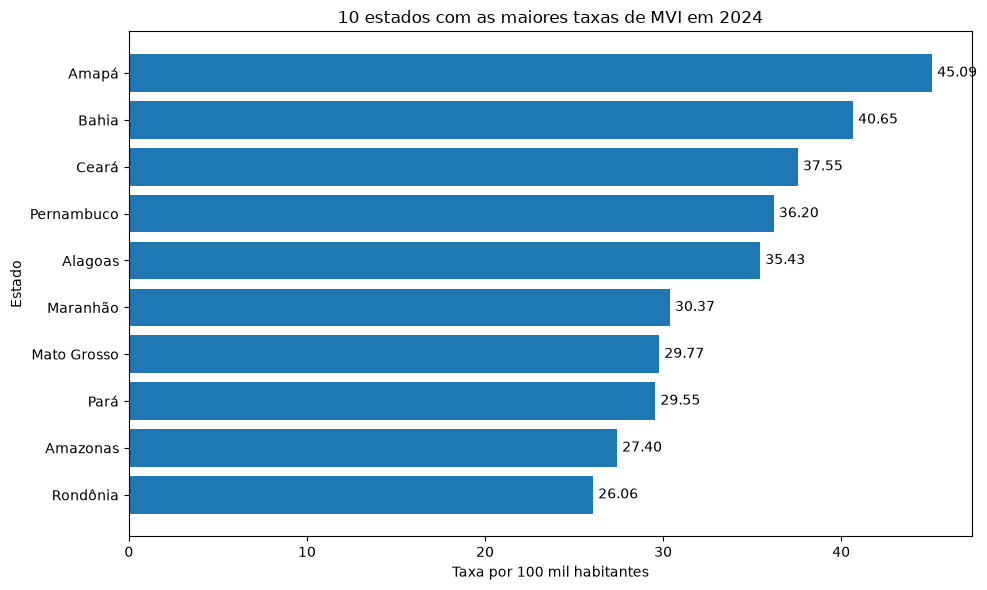

In [29]:
# Selecionando os 10 estados com as maiores taxas de MVI
top10_mvi_2024 = ranking_mvi_2024.head(10)

# Cria o gráfico de barras
plt.figure(figsize=(10, 6))

plt.barh(
    top10_mvi_2024['uf'],
    top10_mvi_2024['taxa_100_mil']
)

# Adiciona os valores das taxas nas barras
for indice, valor in enumerate(top10_mvi_2024['taxa_100_mil']):
    plt.text(
        valor + 0.3,
        indice,
        f'{valor:.2f}',
        va='center'
    )
    
# Adiciona título e nomes dos eixos
plt.title('10 estados com as maiores taxas de MVI em 2024')
plt.xlabel('Taxa por 100 mil habitantes')
plt.ylabel('Estado')

# Coloca a maior taxa no topo
plt.gca().invert_yaxis()

# Ajusta o layout
plt.tight_layout()

# Exibe o gráfico
plt.show()

### Insight

Em 2024, o Amapá apresentou a maior taxa de Mortes Violentas Intencionais (MVI) entre todos os estados analisados, com aproximadamente 45,09 ocorrências por 100 mil habitantes.

Bahia, Ceará, Pernambuco e Alagoas aparecem logo em seguida como os estados com as maiores taxas. Esse resultado mostra que a análise proporcional à população pode destacar estados que não necessariamente possuem os maiores números absolutos de ocorrências.

### Variação da taxa de Mortes Violentas Intencionais (MVI) entre 2023 e 2024

A análise a seguir compara as taxas de Mortes Violentas Intencionais (MVI) entre 2023 e 2024, buscando identificar as Unidades da Federação que apresentaram os maiores aumentos e reduções no período.

In [30]:
# Removendo o Brasil da comparação entre os estados
mvi_estados = mvi[
    mvi['uf'] != 'Brasil'
].copy()

# Organizando as taxas de 2023 e 2024 em colunas separadas
comparacao_mvi = mvi_estados.pivot(
    index='uf',
    columns='ano',
    values='taxa_100_mil'
).reset_index()

# Renomeando as colunas
comparacao_mvi.columns = [
    'uf',
    'taxa_2023',
    'taxa_2024'
]

# Exibindo os primeiros registros
comparacao_mvi.head()

,uf,taxa_2023,taxa_2024
0,Acre,24.413004,20.326334
1,Alagoas,37.593903,35.433638
2,Amapá,64.946116,45.090099
3,Amazonas,33.155912,27.398803
4,Bahia,44.366350,40.645061


In [31]:
# Calculando a variação percentual da taxa de MVI entre 2023 e 2024
comparacao_mvi['variacao_percentual'] = (
    (comparacao_mvi['taxa_2024'] - comparacao_mvi['taxa_2023'])
    / comparacao_mvi['taxa_2023']
) * 100

# Exibe os registros
comparacao_mvi.head()

,uf,taxa_2023,taxa_2024,variacao_percentual
0,Acre,24.413004,20.326334,-16.739726
1,Alagoas,37.593903,35.433638,-5.746317
2,Amapá,64.946116,45.090099,-30.573063
3,Amazonas,33.155912,27.398803,-17.363750
4,Bahia,44.366350,40.645061,-8.387640


In [32]:
# Ordenando os estados pela maior variação percentual
maiores_aumentos = comparacao_mvi.sort_values(
    'variacao_percentual',
    ascending=False
)

# Os 5 estados com os maiores aumentos
maiores_aumentos[
    ['uf', 'taxa_2023', 'taxa_2024', 'variacao_percentual']
].head(5).round(2)

,uf,taxa_2023,taxa_2024,variacao_percentual
9,Maranhão,27.09,30.37,12.11
5,Ceará,33.86,37.55,10.89
25,São Paulo,7.59,8.16,7.50
12,Minas Gerais,14.35,15.07,5.00
23,Santa Catarina,8.50,8.50,-0.02


In [33]:
# Ordenado os estados pela maior redução na taxa de MVI
maiores_reducoes = comparacao_mvi.sort_values(
    'variacao_percentual',
    ascending=True
)

# Os 5 estados com as maiores reduções
maiores_reducoes[
    ['uf', 'taxa_2023', 'taxa_2024', 'variacao_percentual']
].head(5).round(2)

,uf,taxa_2023,taxa_2024,variacao_percentual
2,Amapá,64.95,45.09,-30.57
26,Tocantins,27.44,19.78,-27.91
22,Roraima,25.46,18.55,-27.12
24,Sergipe,30.19,22.78,-24.54
18,Rio Grande do Norte,30.32,24.17,-20.28


In [34]:
# Ordenando os estados pela maior variação positiva na taxa de MVI
maiores_aumentos = comparacao_mvi.sort_values(
    'variacao_percentual',
    ascending=False
)

# Os 5 estados com os maiores aumentos
maiores_aumentos[
    ['uf', 'taxa_2023', 'taxa_2024', 'variacao_percentual']
].head(5).round(2)

,uf,taxa_2023,taxa_2024,variacao_percentual
9,Maranhão,27.09,30.37,12.11
5,Ceará,33.86,37.55,10.89
25,São Paulo,7.59,8.16,7.50
12,Minas Gerais,14.35,15.07,5.00
23,Santa Catarina,8.50,8.50,-0.02


In [35]:
# Selecionando as 5 maiores reduções
top5_reducoes = comparacao_mvi.sort_values(
    'variacao_percentual',
    ascending=True
).head(5)

# Selecionando os 5 maiores aumentos
top5_aumentos = comparacao_mvi.sort_values(
    'variacao_percentual',
    ascending=False
).head(5)

# Juntando os dois grupos
dados_grafico = pd.concat(
    [top5_reducoes, top5_aumentos]
)

# Ordena da menor para a maior variação
dados_grafico = dados_grafico.sort_values(
    'variacao_percentual'
)

# Exibe os dados selecionados
dados_grafico[
    ['uf', 'variacao_percentual']
].round(2)

,uf,variacao_percentual
2,Amapá,-30.57
26,Tocantins,-27.91
22,Roraima,-27.12
24,Sergipe,-24.54
18,Rio Grande do Norte,-20.28
23,Santa Catarina,-0.02
12,Minas Gerais,5.00
25,São Paulo,7.50
5,Ceará,10.89
9,Maranhão,12.11


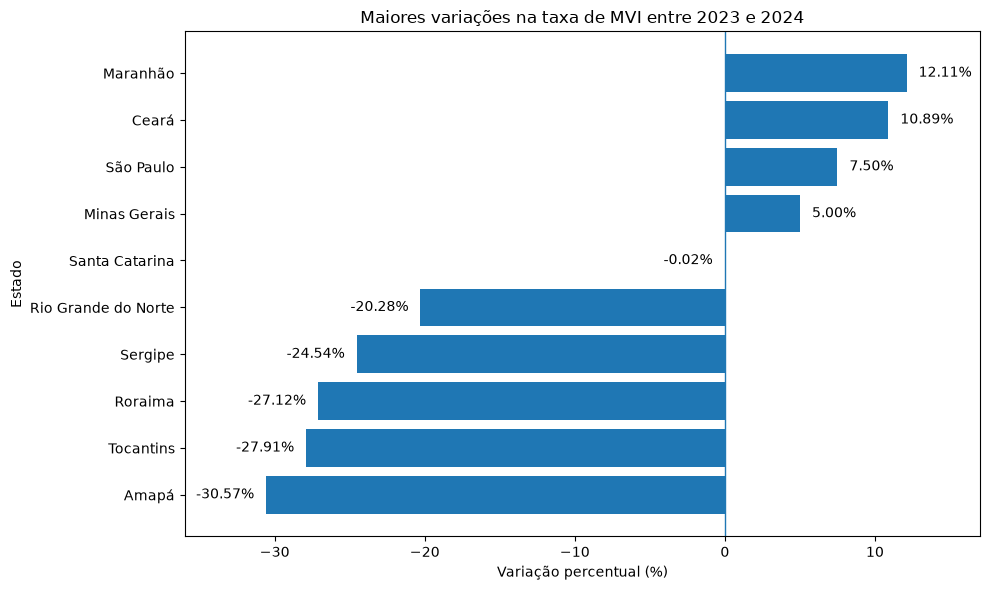

In [36]:
# Gráfico de barras horizontais
plt.figure(figsize=(10, 6))

plt.barh(
    dados_grafico['uf'],
    dados_grafico['variacao_percentual']
)

# Valores das variações nas barras
for indice, valor in enumerate(dados_grafico['variacao_percentual']):
    plt.text(
        valor + (0.8 if valor >= 0 else -0.8),
        indice,
        f'{valor:.2f}%',
        va='center',
        ha='left' if valor >= 0 else 'right'
    )

# Adiciona uma linha indicando a ausência de variação
plt.axvline(0, linewidth=1)

# Cria espaço nas laterais do gráfico
plt.xlim(-36, 17)

# Adiciona título e nomes dos eixos
plt.title('Maiores variações na taxa de MVI entre 2023 e 2024')
plt.xlabel('Variação percentual (%)')
plt.ylabel('Estado')

# Ajusta o layout
plt.tight_layout()

# Exibe o gráfico
plt.show()

### Insight

Entre 2023 e 2024, a taxa de Mortes Violentas Intencionais (MVI) apresentou variações diferentes entre as Unidades da Federação.

O Amapá registrou a maior redução proporcional, com queda de 30,57% na taxa, seguido por Tocantins (-27,91%), Roraima (-27,12%), Sergipe (-24,54%) e Rio Grande do Norte (-20,28%).

Por outro lado, Maranhão apresentou o maior aumento, de 12,11%, seguido por Ceará (10,89%), São Paulo (7,50%) e Minas Gerais (5,00%).

Os resultados indicam que a evolução das MVI não ocorreu de forma uniforme entre os estados, havendo diferenças importantes tanto nas taxas quanto na variação observada entre os dois anos.

## Análise dos casos de Latrocínio

Nesta etapa, são analisados os casos de Latrocínio, comparando os anos de 2023 e 2024 e identificando as Unidades da Federação com as maiores taxas por 100 mil habitantes.

In [37]:
# Exibindo os indicadores disponíveis na base
dados['indicador'].unique()

<StringArray>
[                       'MVI',       'Latrocínio - vítimas',
   'Latrocínio - ocorrências',         'Roubo de celulares',
         'Furto de celulares', 'Roubo e furto de celulares',
     'Homicídios de mulheres',               'Feminicídios']
Length: 8, dtype: str

In [ ]:
# Filtrando apenas os registros de Latrocínio
Latrocinio_vitimas = dados[
    dados['indicador'] == 'Latrocínio - vítimas'
].copy()

# Exibindo os primeiros registros
Latrocinio_vitimas.head()



,uf,ano,indicador,ocorrencias,taxa_100_mil
56,Brasil,2023,Latrocínio - vítimas,1002,0.473322
57,Acre,2023,Latrocínio - vítimas,5,0.570397
58,Alagoas,2023,Latrocínio - vítimas,18,0.559248
59,Amapá,2023,Latrocínio - vítimas,13,1.626781
60,Amazonas,2023,Latrocínio - vítimas,36,0.848942


In [41]:
Latrocinio_ocorrencias = dados[
    dados['indicador'] == 'Latrocínio - ocorrências'
].copy()

Latrocinio_ocorrencias.head()



,uf,ano,indicador,ocorrencias,taxa_100_mil
112,Brasil,2023,Latrocínio - ocorrências,979,0.462457
113,Acre,2023,Latrocínio - ocorrências,4,0.456318
114,Alagoas,2023,Latrocínio - ocorrências,18,0.559248
115,Amapá,2023,Latrocínio - ocorrências,13,1.626781
116,Amazonas,2023,Latrocínio - ocorrências,35,0.825361


In [58]:
# Filtra os dados de Latrocínio de 2024 e remove o Brasil
latrocinio_2024 = Latrocinio_ocorrencias[
    (Latrocinio_ocorrencias['ano'] == 2024) &
    (Latrocinio_ocorrencias['uf'] != 'Brasil')
].copy()

# Ordena os estados pela maior taxa de Latrocínio
ranking_latrocinio_2024 = latrocinio_2024.sort_values(
    'taxa_100_mil',
    ascending=False
)

# Exibe os 10 estados com as maiores taxas
ranking_latrocinio_2024[
    ['uf', 'ocorrencias', 'taxa_100_mil']
].head(10).round(2)

,uf,ocorrencias,taxa_100_mil
150,Maranhão,62,0.88
148,Espírito Santo,36,0.88
163,Roraima,6,0.84
157,Pernambuco,77,0.81
154,Pará,66,0.76
160,Rio Grande do Norte,23,0.67
152,Mato Grosso do Sul,17,0.59
159,Rio de Janeiro,99,0.57
162,Rondônia,10,0.57
158,Piauí,19,0.56


### Estados com as maiores taxas de Latrocínio em 2024

A análise a seguir apresenta as Unidades da Federação com as maiores taxas de Latrocínio (Roubo seguido por morte) por 100 mil habitantes em 2024.

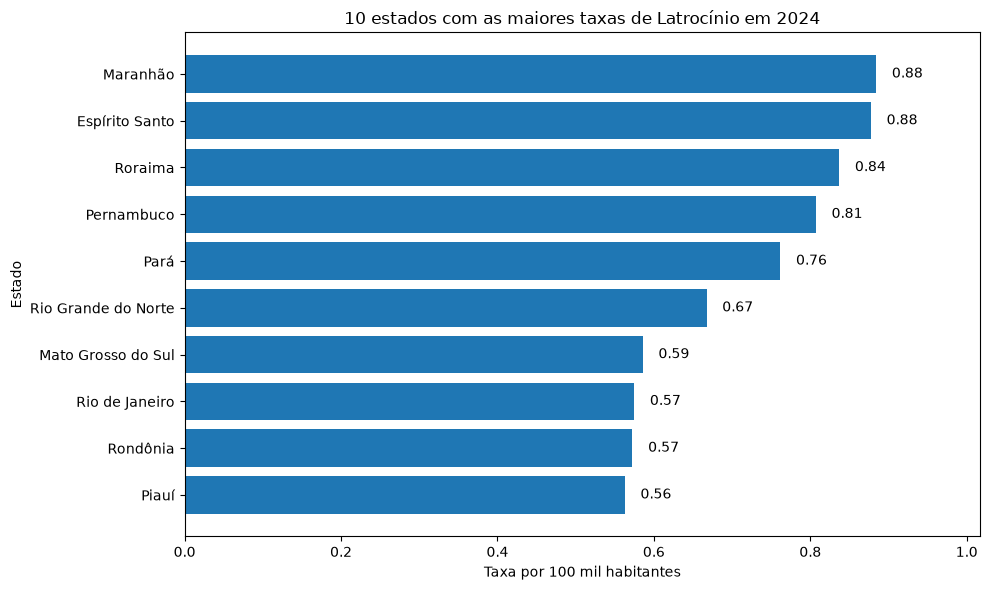

In [62]:
# Seleciona os 10 estados com as maiores taxas de Latrocínio
top10_latrocinio_2024 = ranking_latrocinio_2024.head(10)

# Cria o gráfico de barras
plt.figure(figsize=(10, 6))

plt.barh(
    top10_latrocinio_2024['uf'],
    top10_latrocinio_2024['taxa_100_mil']
)

# Adiciona título e nomes dos eixos
plt.title('10 estados com as maiores taxas de Latrocínio em 2024')
plt.xlabel('Taxa por 100 mil habitantes')
plt.ylabel('Estado')

# Adiciona as taxas nas barras
for i, taxa in enumerate(top10_latrocinio_2024['taxa_100_mil']):
    plt.text(
        taxa + 0.02,
        i,
        f'{taxa:.2f}',
        va='center'
    )

# Adiciona espaço à direita para as taxas
plt.xlim(
    0,
    top10_latrocinio_2024['taxa_100_mil'].max() * 1.15
)    

# Coloca a maior taxa no topo
plt.gca().invert_yaxis()

# Ajusta o layout
plt.tight_layout()

# Exibe o gráfico
plt.show()

## Insight ## 
Em 2024, as maiores taxas de latrocínio ficaram concentradas em um grupo de estados, evidenciando diferenças na incidência do crime entre as unidades federativas. A utilização da taxa por 100 mil habitantes permite uma comparação mais adequada entre estados com populações diferentes. O ranking também serve como ponto de partida para investigar a evolução dessas taxas entre 2023 e 2024.

### Variação da taxa de Latrocínio entre 2023 e 2024

A análise a seguir compara as taxas de Latrocínio (Roubo seguido de morte) entre 2023 e 2024, buscando identificar as Unidades da Federação que apresentaram os maiores aumentos e reduções no período.

In [63]:
# Remove o Brasil da comparação entre os estados
latrocinio_estados = Latrocinio_ocorrencias[
    Latrocinio_ocorrencias['uf'] != 'Brasil'
].copy()

# Organiza as taxas de 2023 e 2024 em colunas separadas
comparacao_latrocinio = latrocinio_estados.pivot(
    index='uf',
    columns='ano',
    values='taxa_100_mil'
).reset_index()

# Renomeia as colunas
comparacao_latrocinio.columns = [
    'uf',
    'taxa_2023',
    'taxa_2024'
]

# Exibe os primeiros registros
comparacao_latrocinio.head()

,uf,taxa_2023,taxa_2024
0,Acre,0.456318,0.113555
1,Alagoas,0.559248,0.155274
2,Amapá,1.626781,0.498233
3,Amazonas,0.825361,0.513874
4,Bahia,0.465311,0.491566


In [64]:
# Calcula a variação percentual da taxa entre 2023 e 2024
comparacao_latrocinio['variacao_percentual'] = (
    (comparacao_latrocinio['taxa_2024'] - comparacao_latrocinio['taxa_2023'])
    / comparacao_latrocinio['taxa_2023']
) * 100

# Ordena da maior redução para o maior aumento
comparacao_latrocinio.sort_values(
    'variacao_percentual'
).round(2)

,uf,taxa_2023,taxa_2024,variacao_percentual
0,Acre,0.46,0.11,-75.11
1,Alagoas,0.56,0.16,-72.24
2,Amapá,1.63,0.50,-69.37
26,Tocantins,1.08,0.38,-64.93
6,Distrito Federal,0.64,0.27,-58.11
3,Amazonas,0.83,0.51,-37.74
22,Roraima,1.29,0.84,-35.34
14,Paraíba,0.58,0.39,-33.66
19,Rio Grande do Sul,0.37,0.27,-28.62
18,Rio Grande do Norte,0.93,0.67,-28.33


## Insight ##
Entre 2023 e 2024, 15 dos 27 estados apresentaram redução na taxa de latrocínio, indicando uma tendência de queda predominante no país. O Acre apresentou a maior redução, de 75,11%, enquanto o Mato Grosso do Sul registrou o maior aumento percentual, de 237,20%. Apesar disso, a análise da variação percentual deve ser feita em conjunto com a taxa absoluta, pois estados que partem de taxas muito baixas podem apresentar grandes variações percentuais mesmo com uma diferença relativamente pequena na taxa.

In [68]:
# Os 5 estados com as maiores reduções
maiores_reducoes = comparacao_latrocinio.sort_values(
    'variacao_percentual'
).head(5)

maiores_reducoes

,uf,taxa_2023,taxa_2024,variacao_percentual
0,Acre,0.456318,0.113555,-75.114946
1,Alagoas,0.559248,0.155274,-72.235136
2,Amapá,1.626781,0.498233,-69.373072
26,Tocantins,1.084743,0.380387,-64.933018
6,Distrito Federal,0.640260,0.268203,-58.110358


In [70]:
# Os 5 estados com os maiores aumentos
maiores_aumentos = comparacao_latrocinio.sort_values(
    'variacao_percentual',
    ascending=False
).head(5)

maiores_aumentos

,uf,taxa_2023,taxa_2024,variacao_percentual
11,Mato Grosso do Sul,0.173731,0.585824,237.201401
5,Ceará,0.260964,0.444028,70.149086
20,Rio de Janeiro,0.377604,0.574924,52.255808
23,Santa Catarina,0.138763,0.198550,43.085867
21,Rondônia,0.402240,0.572663,42.368579


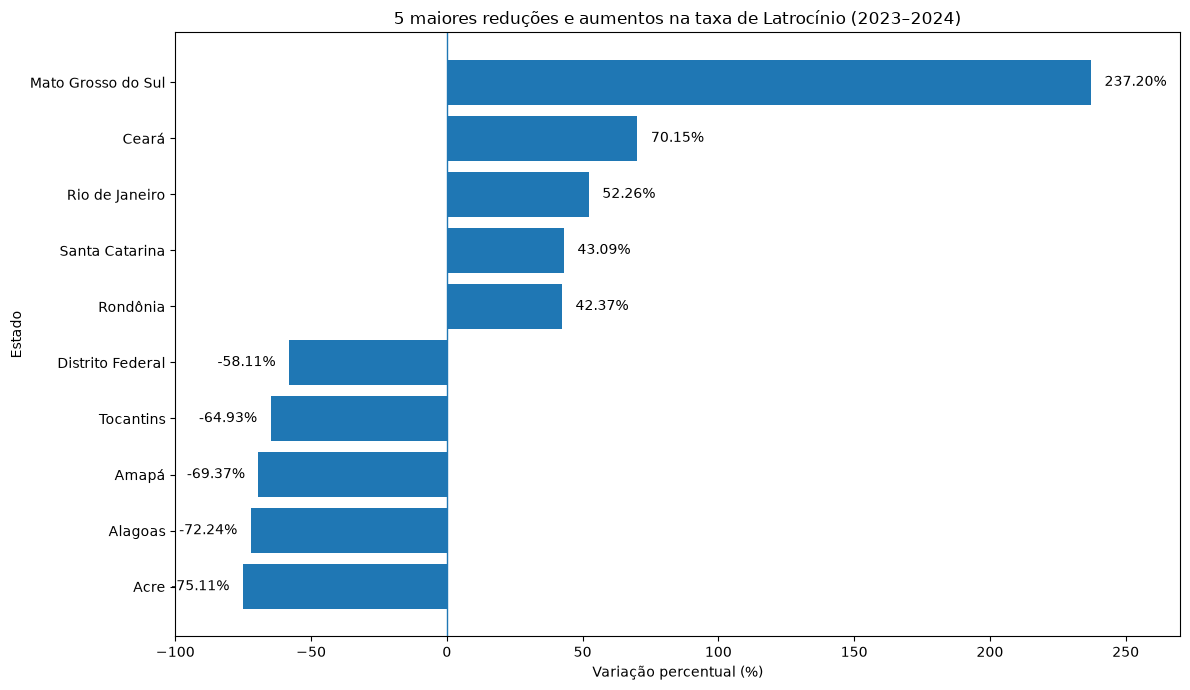

In [75]:
# Ordena os estados pela variação percentual
destaques_latrocinio = destaques_latrocinio.sort_values(
    'variacao_percentual'
)

# Cria o gráfico
plt.figure(figsize=(12, 7))

plt.barh(
    destaques_latrocinio['uf'],
    destaques_latrocinio['variacao_percentual']
)

# Adiciona os valores nas barras
for i, variacao in enumerate(destaques_latrocinio['variacao_percentual']):
    
    if variacao >= 0:
        plt.text(
            variacao + 5,
            i,
            f'{variacao:.2f}%',
            va='center'
        )
    else:
        plt.text(
            variacao - 5,
            i,
            f'{variacao:.2f}%',
            va='center',
            ha='right'
        )

# Linha central em 0%
plt.axvline(0, linewidth=1)

# Define os limites do eixo X
plt.xlim(-100, 270)

plt.title('5 maiores reduções e aumentos na taxa de Latrocínio (2023–2024)')
plt.xlabel('Variação percentual (%)')
plt.ylabel('Estado')

plt.tight_layout()
plt.show()

## Insight ##
Entre 2023 e 2024, o comportamento das taxas de latrocínio apresentou diferenças significativas entre os estados. O Acre registrou a maior redução, com queda de 75,11%, seguido por Alagoas (−72,24%) e Amapá (−69,37%). Por outro lado, o Mato Grosso do Sul apresentou o maior aumento percentual, de 237,20%, seguido pelo Ceará (70,15%) e Rio de Janeiro (52,26%). No entanto, o aumento percentual do Mato Grosso do Sul deve ser interpretado com cautela, pois a taxa passou de apenas 0,17 para 0,59 ocorrências por 100 mil habitantes. Isso demonstra a importância de analisar a variação percentual em conjunto com os valores absolutos das taxas.